# Workshop 3: Exploring IllustrisTNG simulations to derive observationally comparable star formation rates and metallicities

## Notebook 1: IllustrisTNG API and downloading data

Created by Bryanne McDonough and Olivia Curtis
In this notebook, you will be introduced to the different data types availbale for the TNG simulations, and how to use the TNG API to download the data you need. If you haven't download iapi_TNG.py here: https://github.com/bryannemcd/TNG_workshop/blob/main/iapi_TNG.py

IMPORTANT: You will need to update iapi_TNG.py on your machine with the API key you requested from the TNG website. If you do not have an API key, request one here: https:/www.tng-project.org/users/register/

Below, you will find several exercises to get practice working with the different data types available. There are also 'extensions,' prompts for you to explore data that is aligned with your interests.

In [5]:
import os
os.getcwd()



'/Users/marianediby/Desktop'

In [18]:
import sys
sys.executable


'/Library/Developer/CommandLineTools/usr/bin/python3'

In [19]:
!{sys.executable} -m pip install numpy h5py matplotlib


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 8.8 MB/s  0:00:00m 9.6 MB/s eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 9.1 MB/s  0:00:00m 11.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 7.4 MB/s  0:00:01a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 10.3 MB/s  0:00:001.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 9.1 MB/s  0:00:0010.0 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [matplotlib]0m  9/10 [matplotlib]


In [3]:
import iapi_TNG as iapi
#this package contains useful functions for downloading the neccessary data
#make sure you have edited iapi_TNG.py to include your personal API key
import numpy as np
import h5py #most TNG data is downloaded as hdf5 files
import matplotlib.pyplot as plt
import os.path

 
baseUrl = 'https://www.tng-project.org/api/'


/Users/marianediby/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## General simulation data

Using the TNG API, we can explore basic information about the simulations available.

First, define your working directory.

In [6]:
####EDIT THIS FOR YOUR MACHINE#####
dirc='/Users/marianediby/Desktop/TNGWorkshop/'

Then, define which simulation you would like to look at. The options include:

1. TNG100-1 is the highest resolution simulation in the 100 Mpc simulation box
2. TNG50-1 is the highest resolution available in a 50 Mpc box
3. TNG300-1 is the largest volume simulation (300 Mpc)

Here, Lower resolutions are available with -N replacing -1, allowing for testing resolution dependency.
'Dark' simulations are also available that are are dark-matter only runs. Lastly, subboxes are availble that provide higher time resolution

For the exercises in this worrkshop, you will need to use a baryonic simulation, we recommend TNG100-1, TNG50-1, or TNG300-1.

In [7]:
###specify which simulation you want to explore###
sim='TNG100-1'

You can check all available simulations by running the following code block.

In [8]:
import requests

headers = {"api-key": "f47c8519062d199613c99b12244d62ab"}
r = requests.get('https://www.tng-project.org/api/', headers=headers)
print(r.status_code)
print(r.text)


200
{"simulations":[{"name":"Illustris-1","num_snapshots":134,"url":"http://www.tng-project.org/api/Illustris-1/"},{"name":"Illustris-1-Dark","num_snapshots":136,"url":"http://www.tng-project.org/api/Illustris-1-Dark/"},{"name":"Illustris-2","num_snapshots":136,"url":"http://www.tng-project.org/api/Illustris-2/"},{"name":"Illustris-2-Dark","num_snapshots":136,"url":"http://www.tng-project.org/api/Illustris-2-Dark/"},{"name":"Illustris-3","num_snapshots":136,"url":"http://www.tng-project.org/api/Illustris-3/"},{"name":"Illustris-3-Dark","num_snapshots":136,"url":"http://www.tng-project.org/api/Illustris-3-Dark/"},{"name":"TNG100-1","num_snapshots":100,"url":"http://www.tng-project.org/api/TNG100-1/"},{"name":"TNG100-1-Dark","num_snapshots":100,"url":"http://www.tng-project.org/api/TNG100-1-Dark/"},{"name":"TNG100-2","num_snapshots":100,"url":"http://www.tng-project.org/api/TNG100-2/"},{"name":"TNG100-2-Dark","num_snapshots":100,"url":"http://www.tng-project.org/api/TNG100-2-Dark/"},{"na

In [9]:
r=iapi.get(baseUrl)
print(r)

{'simulations': [{'name': 'Illustris-1', 'num_snapshots': 134, 'url': 'http://www.tng-project.org/api/Illustris-1/'}, {'name': 'Illustris-1-Dark', 'num_snapshots': 136, 'url': 'http://www.tng-project.org/api/Illustris-1-Dark/'}, {'name': 'Illustris-2', 'num_snapshots': 136, 'url': 'http://www.tng-project.org/api/Illustris-2/'}, {'name': 'Illustris-2-Dark', 'num_snapshots': 136, 'url': 'http://www.tng-project.org/api/Illustris-2-Dark/'}, {'name': 'Illustris-3', 'num_snapshots': 136, 'url': 'http://www.tng-project.org/api/Illustris-3/'}, {'name': 'Illustris-3-Dark', 'num_snapshots': 136, 'url': 'http://www.tng-project.org/api/Illustris-3-Dark/'}, {'name': 'TNG100-1', 'num_snapshots': 100, 'url': 'http://www.tng-project.org/api/TNG100-1/'}, {'name': 'TNG100-1-Dark', 'num_snapshots': 100, 'url': 'http://www.tng-project.org/api/TNG100-1-Dark/'}, {'name': 'TNG100-2', 'num_snapshots': 100, 'url': 'http://www.tng-project.org/api/TNG100-2/'}, {'name': 'TNG100-2-Dark', 'num_snapshots': 100, 'url

Now, let's investigate the properties of the simulation that you have selected.

To get the URL of the simulation that you are using, append the variable sim to the variable baseUrl that we defined above.

In [10]:
#check the properties of the simulation you have selected
simUrl = baseUrl+sim
print(simUrl) 

https://www.tng-project.org/api/TNG100-1


Feel free to follow that URL to view it in your browser (make sure that you are logged in first!)

Next, we can retrieve and print the metadeta of the specific simulation using iapi.get().

In [11]:
simdata = iapi.get(simUrl)
print(simdata['description'])

Main high-resolution IllustrisTNG100 run including the full TNG physics model.


That is, simdata contains all of the simulation-level metadata for the simulation, saved as a Python dictionary. You can view all of the keys to the dictionary by running the following code block.

In [12]:
simdata.keys()

dict_keys(['name', 'description', 'name_alt', 'boxsize', 'z_start', 'z_final', 'cosmology', 'omega_0', 'omega_L', 'omega_B', 'hubble', 'physics_model', 'has_cooling', 'has_starformation', 'has_winds', 'has_blackholes', 'mass_gas', 'mass_dm', 'softening_dm_comoving', 'softening_stars_comoving', 'softening_blackholes_comoving', 'softening_gas_comoving', 'softening_dm_max_phys', 'softening_stars_max_phys', 'softening_blackholes_max_phys', 'softening_gas_max_phys', 'softening_gas_factor', 'softening_gas_comoving_min', 'num_dm', 'num_tr_mc', 'num_tr_vel', 'longids', 'is_uniform', 'is_zoom', 'is_subbox', 'num_files_snapshot', 'num_files_groupcat', 'num_files_rockstar', 'num_files_lhalotree', 'num_files_sublink', 'num_files_ctrees', 'filesize_lhalotree', 'filesize_sublink', 'filesize_ctrees', 'filesize_ics', 'filesize_simulation', 'has_fof', 'has_subfind', 'has_rockstar', 'has_lhalotree', 'has_sublink', 'has_ctrees', 'permission_required', 'num_snapshots', 'url', 'parent_simulation', 'child_s

### Exercise (don't skip!): Find value of Hubble's constant used in the simulation you chose to explore
In simulations, units often include 'little h' or Hubble's constant divided by 100.

In these simulations, the value of h is stored in the simulation data as the key 'hubble'.

In the following code block, determine the value of h from the simulation's metadata. (Hint: should find h=0.6774)

In [13]:
h = simdata.get('hubble')
print(h) #Fill in this code

0.6774


### Group catalogs

Group catalogs contain properies of all identified halos or subhalos (galaxies) in a given snapshot. These are good for obtaining masses, positions, and other global properties. You can check out details about the available fields here: https://www.tng-project.org/data/docs/specifications/#sec2 

In iapi_TNG there are two similar functions that obtain a field for all subhalos or all halos in a given simulation at a given snapshot:

> getSubhaloField(field, simulation='TNG100-1', snapshot=99, fileName='tempCat', rewriteFile=1)

> getHaloField(field, simulation='TNG100-1', snapshot=99, fileName='tempCat', rewriteFile=1)

- field (str): name of field to be returned from the table linked above, e.g. 'SubhaloPos'
- simulation (str): name of simulation, e.g. 'TNG100-1'
- snapshot (int): snapshot to pull data from. For TNG, snapshot=99 is z=0, which is the default
- fileName (str): path to the file where you want to save the data, recommended to avoid repeated API requests
- rewriteFile (0 or 1): if 0 (recommended), will attempt to pull from an existing file (fileName) before downloading; if 1 will download and overwrite

Now let's fetch the fields that we will want for our later analysis.

First, the 'SubhaloFlag' indicates whether a subhalo is cosmological in origin. Generally, we only want to use data from subhalos that have flag=1.

For now, we will pull the subhalo flags with

In [14]:

flag=iapi.getSubhaloField('SubhaloFlag',simulation=sim,fileName=dirc+'catalogs/SubhaloFlag',rewriteFile=0)

Next, we can pull all of the positions of the subhalos. Note that the positions are in units of comoving Kpc/h.

In [15]:
pos=iapi.getSubhaloField('SubhaloPos',fileName='catalogs/SubhaloPos',rewriteFile=0)

Next, let's fetch a field that will tell us about the mass of the galaxy. 'SubhaloMassType' gives the total mass of all bound particles, separated by particle type.

In [16]:
print(dirc)

/Users/marianediby/Desktop/TNGWorkshop/


In [17]:
#let's fetch a field that will tell us about the mass of the galaxy
#SubhaloMassType gives the total mass of all bound particles, separated by particle type
mass=iapi.getSubhaloField('SubhaloMassType',simulation=sim,fileName=dirc+'catalogs/MassType',rewriteFile=0)
print(mass.shape)

(4371211, 6)


Notice that there are 6 entries for each subhalo, one for each particle type:

0. gas
1. dark matter
2. unused
3. tracers (you can ignore these)
4. stars/wind
5. black holes.

To pull the stellar masses, we can splice the previous with the following code.

In [18]:
#Pull the stellar mass: 
stellar_mass=mass[:,4]

According to the documentation, these masses are given in units of 10^10 M_\odot / h. To convert those to physical units we can run.

In [19]:
stellar_mass=stellar_mass*10**10/h
#running into an error? did you define h above?

We will also be working with star formation rates. 

The subhalo catalog includes 'SubhaloSFR', which is the sum of SFRs over all gas particles bound to the subhalo (i.e., an instantaneous star formation rate).
These are NOT directly comparable to SFRs obtained from observations since observational tracers generally detect already formed stars, not stars about to be formed

If we want to get more comparable SFRs, we'll have to dig into particle data or merger trees, which we will get to later.

For now, let's pull the instantaneous star formation rates.

In [20]:
sfr_inst = iapi.getSubhaloField('SubhaloSFR',simulation = sim,fileName=dirc+'SubhaloSFR',rewriteFile=0)

### Exercise:

There are several other fields relating to galaxy mass. Review those found at the link above and fetch at least one other field relating to mass. Later, we will test the effect of using other definitions of mass on the global star formation main sequence. Generally, you will want to use a mass that is most comparable to how mass was measured in observations you want to compare to.


In [21]:
### Pull an additional stellar mass field ###

stellar_mass=mass[:,4]

In [22]:
### Convert this mass field to physical units ###

stellar_mass=stellar_mass*10**10/h
print(stellar_mass)

[3.70558476e+12 5.58791711e+11 6.27139609e+11 ... 0.00000000e+00
 0.00000000e+00 0.00000000e+00]


### Exercise: Metallicities
Interested in metallicities? Reveiw the fields availalbe in the data specifications. Make sure to scroll all the way through, there are many different metallicity fields, based on both stars and gas. 

In [59]:
### Download metallicity fields ###
pos = iapi.getSubhaloField(
    'SubhaloGasMetallicity',
    simulation=sim,
    fileName=dirc + 'catalogs/SubhaloGasMetallicity',
    rewriteFile=1
)

HTTPError: 504 Server Error: Gateway Time-out for url: https://data-eu.tng-project.org/file/groupcat/L75n1820TNG/99/req.Subhalo.SubhaloGasMetallicity/?token=f88bdac4b17b3b2c110e

### Data Preprocessing

We need to clean our data before we can use them. This usually involves making cuts to galaxy masses, magnitudes, star formation rates, etc.

First, it is useful to keep track of each subhalo's ID (i.e., subID), which is the objects index into the fields.

In [25]:
subID=np.arange(0,len(stellar_mass))

Next, let's mask out any galaxy that is not cosmological in origin and that has stellar masses <= 10^8 solar masses.

In [26]:
mask = (flag==1) & (stellar_mass>10**8)

print("Before trimming, there are ", len(stellar_mass), ' subhalos in our catalog')

IDs=subID[mask]
s_mass=stellar_mass[mask]
sfr_i = sfr_inst[mask]

print("After trimming, there are ", len(s_mass), ' subhalos in our catalog')

Before trimming, there are  4371211  subhalos in our catalog
After trimming, there are  49914  subhalos in our catalog


Lastly, we will save these fields as a Python dictionary called galcat. We will be using this catalog throughout the rest of this workshop.

In [31]:
galcat = {
    'subID' : IDs,
    'pos' : pos,
    'M_*' : s_mass,
    'SFR_inst': sfr_i
}

#save the galaxy catalog for later use
np.save(dirc+'galcat', galcat)

In [ ]:
p

## Merger Trees

Tracing a subhalo through cosmic time can be complicated by the major and minor mergers that ultimately form a z=0 galaxy. The merger trees trace the most massive progenitor of a subhalos through previous snapshots. See the TNG data specifications for more information: https://www.tng-project.org/data/docs/specifications/#sec2

In this workshop, we will be using the SubLink merger trees.

iapi_TNG contains the function gettree(snapnum,subID), which obtains the tree for a given galaxy. The trees contain all the fields in the Halo and Subhalo group catalogs, for each snapshot. Subhalo information will always be for the progenitor of the subID at snapnum. The group/halo of a subhalo may change, so the group information in previous snapshots may not be for the group the subhalo is a member of at snapnum.

getredshift(snapnum) is another useful function in iapi_TNG. This returns the redfshift of a given snapshot. 

For this notebook, let's work with a single subhalo at a subhalo in the top middle of our sample (where galaxy indices are very roughly ordered from largest to smalles). Specifically, let's work with the galaxy whose index into IDs is 24957 (this object has a corresponding ID of 565261).

In [29]:
this_index = 24957
sub=IDs[this_index]
print(sub)

565261


Next, let's use iapi.gettree() to pull the merger tree of this subhalo.

In [48]:
!mkdir trees

mkdir: trees: File exists


In [49]:
subTreeFile = iapi.gettree(99,sub)
print(subTreeFile)

trees/sublink_mpb_565261.hdf5


This just saved the file '/trees/sublink_mpb_565261.hdf5' into your working directory. We can open that .hdf5 file using h5py.

In [34]:
#open the hdf5 file that contains the tree
subTree = h5py.File(subTreeFile,'r')

We can then check the fields that we have to work with.

In [35]:
print(subTree.keys())

<KeysViewHDF5 ['DescendantID', 'FirstProgenitorID', 'FirstSubhaloInFOFGroupID', 'GroupBHMass', 'GroupBHMdot', 'GroupCM', 'GroupFirstSub', 'GroupGasMetalFractions', 'GroupGasMetallicity', 'GroupLen', 'GroupLenType', 'GroupMass', 'GroupMassType', 'GroupNsubs', 'GroupPos', 'GroupSFR', 'GroupStarMetalFractions', 'GroupStarMetallicity', 'GroupVel', 'GroupWindMass', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', 'Group_R_Mean200', 'Group_R_TopHat200', 'LastProgenitorID', 'MainLeafProgenitorID', 'Mass', 'MassHistory', 'NextProgenitorID', 'NextSubhaloInFOFGroupID', 'NumParticles', 'RootDescendantID', 'SnapNum', 'SubfindID', 'SubhaloBHMass', 'SubhaloBHMdot', 'SubhaloBfldDisk', 'SubhaloBfldHalo', 'SubhaloCM', 'SubhaloGasMetalFractions', 'SubhaloGasMetalFractionsHalfRad', 'SubhaloGasMetalFractionsMaxRad', 'SubhaloGasMetalFractionsSfr', 'SubhaloGasMetalFractionsSfrWeighted', 'SubhaloGasMetallicity', 'SubhaloGasMetallicityHalfRad'

Next, we will pull the snapshot numbers that correspond to each entry in each of the fields for this tree.

In [36]:
#pull the snapshot numbers that correspond to each entry in each of the fields for this tree
snaps = subTree['SnapNum'][:]
print(snaps)

[99 98 97 96 95 94 93 92 91 90 89 88 87 86 85 84 83 82 81 80 79 78 77 76
 75 74 73 72 71 70 69 68 67 66 65 64 63 62 61 60 59 58 57 56 55 54 53 52
 51 50 49 48 47 46 45 44 43 42 41 40 39 38 37 36 35 34 33 32 31 30 29 28
 27 26 25 24 23 22 21 20 19 18 17 16 15 14 13 12 11 10  9  8  7  6  5]


Notice how the first entry corresponds to z=0! The latest entries are first, while the earliest entries are last

Some subhalos have shorter merger trees than others. This particular merger tree indicates that the pregenitor of our test subhalo formed during snapshot 5. 

We can determine what redshift this corresponds to using iapi.getredshift()

In [37]:
#What redshift does the earliest snapshot correspond to?
formation_redshift = iapi.getredshift(snaps[-1])

print("The progenitor of our test subhalo formed during redshift z = ", formation_redshift)

The progenitor of our test subhalo formed during redshift z =  9.38877127194055


We can also do this generally for all snapshots.

In [38]:
#construct an array of redshifts corresponding to snaps
z = iapi.getredshift(snaps)
print(z)

[2.22044604925031e-16, 0.00952166696794476, 0.0239744283827625, 0.0337243718735154, 0.0485236299818059, 0.058507322794513, 0.0736613846564387, 0.0838844307974793, 0.0994018026302219, 0.109869940458825, 0.125759332411261, 0.141876203969562, 0.152748768902381, 0.169252033243611, 0.180385261705749, 0.19728418237601, 0.214425035514495, 0.225988386260198, 0.24354018155467, 0.261343256161012, 0.27335334657844, 0.297717684517447, 0.310074120127834, 0.328829724205954, 0.347853841858178, 0.360687657261817, 0.380167867260239, 0.399926964613563, 0.419968941997267, 0.440297849247743, 0.460917794180647, 0.481832943420951, 0.503047523244883, 0.524565820433923, 0.546392183141022, 0.575980845107887, 0.598543288187567, 0.621428745242514, 0.644641840684537, 0.676110411213478, 0.700106353718523, 0.732636182022312, 0.757441372615853, 0.791068248946339, 0.816709979011851, 0.851470900624649, 0.886896937575248, 0.923000816177909, 0.950531351585033, 0.99729422578194, 1.03551044566414, 1.07445789454767, 1.1141

### Exercise: Construct a plot of star formation rate versus redshift for this subhalo


In [43]:
with h5py.File(subTreeFile, 'r') as f:
    print(list(f.keys()))

['DescendantID', 'FirstProgenitorID', 'FirstSubhaloInFOFGroupID', 'GroupBHMass', 'GroupBHMdot', 'GroupCM', 'GroupFirstSub', 'GroupGasMetalFractions', 'GroupGasMetallicity', 'GroupLen', 'GroupLenType', 'GroupMass', 'GroupMassType', 'GroupNsubs', 'GroupPos', 'GroupSFR', 'GroupStarMetalFractions', 'GroupStarMetallicity', 'GroupVel', 'GroupWindMass', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', 'Group_R_Mean200', 'Group_R_TopHat200', 'LastProgenitorID', 'MainLeafProgenitorID', 'Mass', 'MassHistory', 'NextProgenitorID', 'NextSubhaloInFOFGroupID', 'NumParticles', 'RootDescendantID', 'SnapNum', 'SubfindID', 'SubhaloBHMass', 'SubhaloBHMdot', 'SubhaloBfldDisk', 'SubhaloBfldHalo', 'SubhaloCM', 'SubhaloGasMetalFractions', 'SubhaloGasMetalFractionsHalfRad', 'SubhaloGasMetalFractionsMaxRad', 'SubhaloGasMetalFractionsSfr', 'SubhaloGasMetalFractionsSfrWeighted', 'SubhaloGasMetallicity', 'SubhaloGasMetallicityHalfRad', 'SubhaloGasM

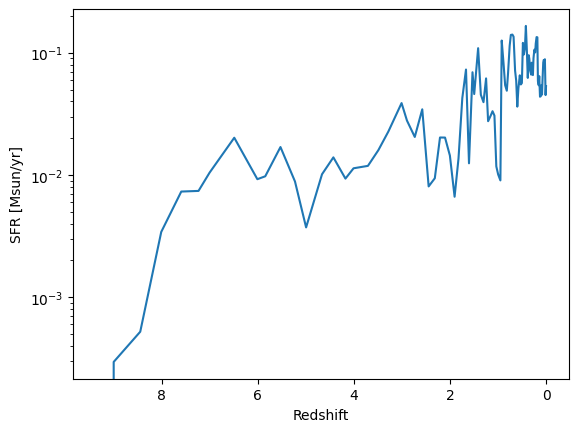

In [44]:
### Plot SFR versus redshift for this subhalo ###
#hint: pull the SubhaloSFR field from the merger tree first
import matplotlib.pyplot as plt
with h5py.File(subTreeFile, 'r') as f:
    sfr = np.array(f['SubhaloSFR'])
    snap = np.array(f['SnapNum'])

snaps = iapi.get(f"https://www.tng-project.org/api/{sim}/snapshots/")
snap_to_z = {s['number']: s['redshift'] for s in snaps}

z = np.array([snap_to_z[s] for s in snap])

order = np.argsort(z)
z = z[order]
sfr = sfr[order]

plt.plot(z, sfr)
plt.yscale('log')
plt.gca().invert_xaxis()
plt.xlabel('Redshift')
plt.ylabel('SFR [Msun/yr]')
plt.show()



### Extension: Plot other properties versus redshift for this subhalo
What other properties would be interested to explore as a function of redshift?

In [ ]:
### Extension ###

### Particle Data
Now, we can download some particle data that will allow us to compute luminosity-weighted ages and time-averaged star formation rates for a galaxy. Full snapshots contain way more data than we need, so we can instead pull the parameters we want from 'cutouts' - files that contain data for all particles bound to a subhalo.

First, define the particle type that we are interested in

In [45]:
parttype='stars'

as well as the particle fields that we want to pull.

In [46]:
particle_fields = 'Coordinates,Masses,GFM_Metallicity,GFM_StellarFormationTime,GFM_InitialMass,GFM_StellarPhotometrics'

Note that for time-averaged SFR calculations, the initial mass of a star should be used.

Lastly, use iapi.getSubcutout to pull the particle data for each of these fields.

In [50]:
cut_file = iapi.getSubcutout(sub, \
                             parttype, \
                             particle_fields, \
                             sim=sim, \
                             snapnum=99, \
                             fName=dirc+'cutouts/'+parttype+'_'+str(sub))
print(cut_file)

#running into issues? follow the sub_url that getSubcutout prints to check if a cutout exists for this subhalo

http://www.tng-project.org/api/TNG100-1/snapshots/99/subhalos/565261/
/Users/marianediby/Desktop/TNGWorkshop/cutouts/stars_565261.hdf5


This cutout file was saved to the file /cutouts/stars_565261.hdf5 in your work directory. Feel free to open this catalog on your own and explore the particle data yourself.

### Supplementary Data Catalogs
Rather than instantaneous star formation rates from gas particles, a more observationally-comparable measure is time-averaged star formation rates. Later in this workshop we will cover how to obtain these yourself, but for now we can make use of a supplementary catalog: https://www.tng-project.org/data/docs/specifications/#sec5b

First, we can download the catalog for the simulation of our choice, but note that some catalogs are only available for certain simulations.

In [51]:
#this is a large file, it may take awhile to download
SFRf=dirc+'SubhaloSFR_ta'

#If statement checks to see if the file already exists
#it's here to make sure you do not download
#this large file again by accident!
if os.path.exists(SFRf): 
    sfr_cat=SFRf+'.hdf5'
else: 
    sfr_cat = iapi.get('https://www.tng-project.org/api/'+sim+'/files/star_formation_rates.hdf5', fName=SFRf)

Then, we can open the supplementary catalog that corresponds to the snapshot of interest with h5py.

In [52]:
supp_catalog = h5py.File(sfr_cat,'r')

Looking at its keys, we see it has an entry for multiple snapshots.

In [53]:
supp_catalog.keys()

<KeysViewHDF5 ['Header', 'Snapshot_1', 'Snapshot_10', 'Snapshot_11', 'Snapshot_12', 'Snapshot_13', 'Snapshot_14', 'Snapshot_15', 'Snapshot_16', 'Snapshot_17', 'Snapshot_18', 'Snapshot_19', 'Snapshot_2', 'Snapshot_20', 'Snapshot_21', 'Snapshot_22', 'Snapshot_23', 'Snapshot_24', 'Snapshot_25', 'Snapshot_26', 'Snapshot_27', 'Snapshot_28', 'Snapshot_29', 'Snapshot_3', 'Snapshot_30', 'Snapshot_31', 'Snapshot_32', 'Snapshot_33', 'Snapshot_34', 'Snapshot_35', 'Snapshot_36', 'Snapshot_37', 'Snapshot_38', 'Snapshot_39', 'Snapshot_4', 'Snapshot_40', 'Snapshot_41', 'Snapshot_42', 'Snapshot_43', 'Snapshot_44', 'Snapshot_45', 'Snapshot_46', 'Snapshot_47', 'Snapshot_48', 'Snapshot_49', 'Snapshot_5', 'Snapshot_50', 'Snapshot_51', 'Snapshot_52', 'Snapshot_53', 'Snapshot_54', 'Snapshot_55', 'Snapshot_56', 'Snapshot_57', 'Snapshot_58', 'Snapshot_59', 'Snapshot_6', 'Snapshot_60', 'Snapshot_61', 'Snapshot_62', 'Snapshot_63', 'Snapshot_64', 'Snapshot_65', 'Snapshot_66', 'Snapshot_67', 'Snapshot_68', 'Snaps

Let's load the dictionary that corresponds to snapshot 99 and look at its keys.

Notice that there are several options. There are SFRs that are calculated within certain apertures and SFRs calculated over different timescales. When comparing simulations to observations, it's important to use a timescale comparable to the observational tracer (e.g. Halpha roughly traces 10Myrs)

In [54]:
supp_catalog_snap99 = supp_catalog['Snapshot_99']
print(supp_catalog_snap99.keys())

<KeysViewHDF5 ['SFR_MsunPerYrs_in_InRad_1000Myrs', 'SFR_MsunPerYrs_in_InRad_100Myrs', 'SFR_MsunPerYrs_in_InRad_10Myrs', 'SFR_MsunPerYrs_in_InRad_200Myrs', 'SFR_MsunPerYrs_in_InRad_50Myrs', 'SFR_MsunPerYrs_in_all_1000Myrs', 'SFR_MsunPerYrs_in_all_100Myrs', 'SFR_MsunPerYrs_in_all_10Myrs', 'SFR_MsunPerYrs_in_all_200Myrs', 'SFR_MsunPerYrs_in_all_50Myrs', 'SFR_MsunPerYrs_in_r30pkpc_1000Myrs', 'SFR_MsunPerYrs_in_r30pkpc_100Myrs', 'SFR_MsunPerYrs_in_r30pkpc_10Myrs', 'SFR_MsunPerYrs_in_r30pkpc_200Myrs', 'SFR_MsunPerYrs_in_r30pkpc_50Myrs', 'SFR_MsunPerYrs_in_r5pkpc_1000Myrs', 'SFR_MsunPerYrs_in_r5pkpc_100Myrs', 'SFR_MsunPerYrs_in_r5pkpc_10Myrs', 'SFR_MsunPerYrs_in_r5pkpc_200Myrs', 'SFR_MsunPerYrs_in_r5pkpc_50Myrs', 'SubfindID']>


Let's pull the fields 'SubfindID' and 'SFR_MsunPerYrs_in_all_10Myrs' which pull their subfindID and star formation rate in the past 10 Myrs, respectively. 

In [55]:
SFR_subID = supp_catalog_snap99['SubfindID'][:]
SFR_all_10 = supp_catalog_snap99['SFR_MsunPerYrs_in_all_10Myrs'][:]

Recall that we had previously trimmed the galaxy catalog that we were using. If we want to append these time-averaged star formation rates to that catalog, then we will need to match the subIDs between the two catalogs.

First, make an empty array that is the same shape as galcat. We will populate this array with time-averaged star formation rates.

In [56]:
SFR_10=np.empty(len(IDs))

Next, let's loop over every entry in galcat. We will then find the entry in SFR_subID (from the supplementary catalog) that has the same subID as the current galcat entry.

In [57]:
#For each entry in galcat:
for i in range(0,len(IDs)):
    
    #we only want to match our
    #current entry in galcat with its
    #corresponding entry in the 
    #supplementary catalog.
    mask = SFR_subID==IDs[i]
    
    #Try to assign the time-averaged SFR 
    #not all galaxies in our sample may 
    #have SFRs computed in this catalog
    try: 
        SFR_10[i]=SFR_all_10[mask]
    except: 
        SFR_10[i]=np.nan
        
print(SFR_10)
print(SFR_10.shape)

/var/folders/h6/pzxlkjxs2pzbjl1_f29hrlxm0000gn/T/ipykernel_30599/4219987981.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  SFR_10[i]=SFR_all_10[mask]


[ 3.47663982  0.86949015 17.46876928 ...  0.          0.
  0.        ]
(49914,)


Lastly, let's update our galcat.

In [58]:
galcat['SFR_all_10']=SFR_10
np.save(dirc+'galcat', galcat)

### Extension: Edit the code above to use a different aperature, or save additional timescales

In [ ]:
### Extension ###

